# lcbinint / VBM limb-darkened light curve

This notebook uses the public `LightCurve` callable API with a parameter dictionary. The example focuses on a limb-darkened finite-source light curve and compares it against VBM when available.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import collections
import math
import statistics
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

for build_dir in ("build_new", "build"):
    build_path = next(
        (root / build_dir
         for root in (Path.cwd(), *Path.cwd().parents)
         if (root / build_dir).is_dir()),
        None,
    )
    if build_path is not None:
        sys.path.insert(0, str(build_path))
        break

import lcbinint

try:
    import VBMicrolensing
except ImportError:
    VBMicrolensing = None


In [2]:
@dataclass(frozen=True)
class Case:
    s: float = 1.2
    q: float = 1.0e-2
    q2: float = 1.0e-3
    sep2: float = 1.0
    ang: float = 0.5
    t0: float = 0.0
    tE: float = 1.0
    u0: float = 0.05
    alpha: float = 0.0
    rho: float = 5.0e-3
    t_min: float = -0.8
    t_max: float = 0.8
    n_times: int = 400


case = Case()
times = np.linspace(case.t_min, case.t_max, case.n_times)

params = {
    "s": case.s, "q": case.q, "q2": case.q2,
    "sep2": case.sep2, "ang": case.ang,
    "u0": case.u0, "alpha": case.alpha,
    "rho": case.rho, "t0": case.t0, "tE": case.tE,
}

options = lcbinint.Options(param_type="vbm", source_bins=50, max_source_bins=400, reltol=1.0e-3)
limb_darkening = lcbinint.LimbDarkening.linear(0.5)
lightcurve = lcbinint.LightCurve(
    lens="triple_lens",
    options=options,
    limb_darkening=limb_darkening,
)


In [3]:
def timed_median(func, repeats=5):
    samples = []
    value = None
    for _ in range(repeats):
        start = time.perf_counter()
        value = func()
        samples.append(time.perf_counter() - start)
    return value, statistics.median(samples), samples


def _vbm_array(p):
    """Convert params dict to VBM's TripleLightCurve log-parameter array."""
    return [
        math.log(p["s"]), math.log(p["q"]), p["u0"], p["alpha"], math.log(p["rho"]),
        math.log(p["tE"]), p["t0"],
        math.log(p["sep2"]), math.log(p["q2"]), p["ang"],
    ]


def evaluate_lcbinint():
    t = times.tolist()
    lightcurve(t, params)
    values, elapsed, samples = timed_median(lambda: np.asarray(lightcurve(t, params)))
    info = lightcurve.info(t, params)
    return values, elapsed, samples, info


def evaluate_vbm():
    if VBMicrolensing is None:
        return np.full_like(times, np.nan), np.nan, []
    vbm = VBMicrolensing.VBMicrolensing()
    vbm.Tol = 1.0e-3
    vbm.a1 = 0.5
    vbm.a2 = 0.0
    vbm_arr = _vbm_array(params)
    t = times.tolist()
    vbm.TripleLightCurve(vbm_arr, t)
    values, elapsed, samples = timed_median(
        lambda: np.asarray(vbm.TripleLightCurve(vbm_arr, t)[0])
    )
    return values, elapsed, samples


def spread(samples):
    values = [1.0e3 * sample / times.size for sample in samples]
    return f"median={statistics.median(values):.4f} min={min(values):.4f} max={max(values):.4f}"


def relative_error(reference, values):
    return np.abs(values - reference) / np.maximum(np.abs(reference), 1.0e-12)


lc_values, lc_elapsed, lc_samples, lc_info = evaluate_lcbinint()
vbm_values, vbm_elapsed, vbm_samples = evaluate_vbm()

lc_ms = 1.0e3 * lc_elapsed / times.size
vbm_ms = 1.0e3 * vbm_elapsed / times.size
rel = relative_error(vbm_values, lc_values)
method_mix = collections.Counter(lc_info.finite_source_method_names)

print("limb-darkened finite-source light curve")
print(f"lcbinint: {lc_ms:.4f} ms/point")
if np.isfinite(vbm_ms):
    print(f"VBM     : {vbm_ms:.4f} ms/point")
    print("timing spread")
    print(f"  lcbinint: {spread(lc_samples)}")
    print(f"  VBM     : {spread(vbm_samples)}")
    print(
        "relative error vs VBM: "
        f"max={np.nanmax(rel):.3e}, p99={np.nanpercentile(rel, 99):.3e}, "
        f"median={np.nanmedian(rel):.3e}, rms={np.sqrt(np.nanmean(rel * rel)):.3e}"
    )
print(f"method mix: {dict(method_mix)}")


limb-darkened finite-source light curve
lcbinint: 0.4364 ms/point
VBM     : 3.4447 ms/point
timing spread
  lcbinint: median=0.4364 min=0.4357 max=0.4382
  VBM     : median=3.4447 min=3.4441 max=3.4451
relative error vs VBM: max=5.789e-04, p99=5.371e-04, median=4.139e-05, rms=1.704e-04
method mix: {'point_source': 291, 'inverse_ray_cartesian': 70, 'hexadecapole': 39}


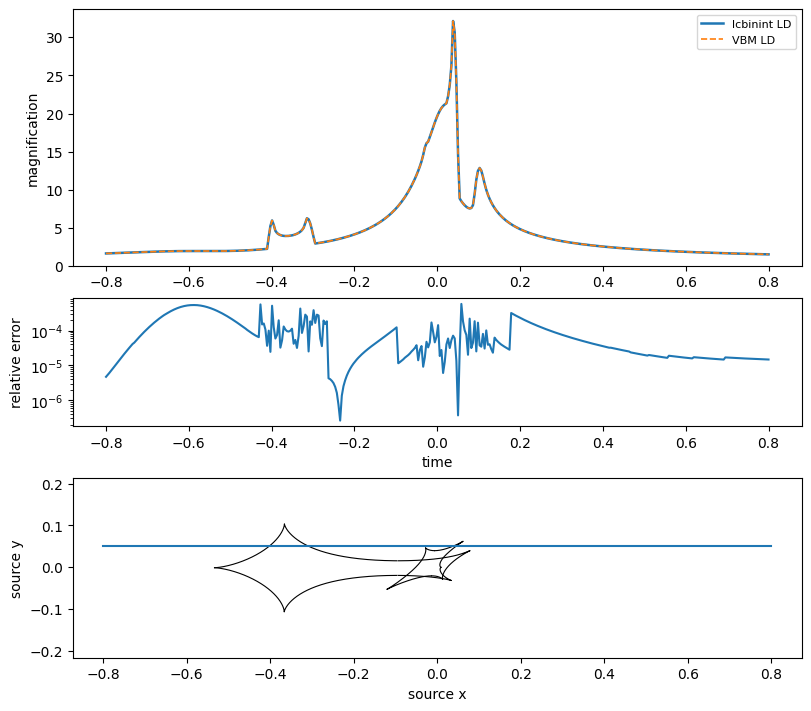

In [4]:
trajectory = lightcurve.source_trajectory(times.tolist(), params)
caustics = lightcurve.caustics(params, n_points=900)

fig, (ax_mag, ax_res, ax_geo) = plt.subplots(
    3,
    1,
    figsize=(8, 7),
    gridspec_kw={"height_ratios": [2.0, 1.0, 1.4]},
    constrained_layout=True,
)

ax_mag.plot(times, lc_values, label="lcbinint LD", lw=1.8)
if np.all(np.isfinite(vbm_values)):
    ax_mag.plot(times, vbm_values, "--", label="VBM LD", lw=1.2)
ax_mag.set_ylabel("magnification")
ax_mag.legend(fontsize=8)

if np.all(np.isfinite(vbm_values)):
    ax_res.semilogy(times, rel)
else:
    ax_res.text(0.5, 0.5, "VBM is not installed", ha="center", va="center")
ax_res.set_ylabel("relative error")
ax_res.set_xlabel("time")

for xs, ys in zip(caustics.x, caustics.y):
    ax_geo.plot(xs, ys, color="black", lw=0.8)
ax_geo.plot(trajectory.x, trajectory.y, color="tab:blue", lw=1.5)
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set_xlabel("source x")
ax_geo.set_ylabel("source y")
plt.show()
